In [ ]:
# Ensure the notebook uses the repository root as its working directory whether launched from notebooks/ or the repository root
import os, sys
from pathlib import Path
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


In [1]:
from paradigm.turbo import TurboM_Plus
import numpy as np
import torch
import math
import matplotlib.pyplot as plt
import re, json, os
import subprocess, time
from paradigm.netlist_utils import CircuitParams, FitnessFunction_Prallel_Tailor, make_fitness_function
import csv
import pandas as pd

## Function Definitions

In [2]:
def draw_search_path(csv_path, ckt_name, weight_vector='[1, 1, 1]'):
    '''
    Display the search path for weight_vector: dark-blue circles denote non-STALE points and light-blue × markers denote STALE points
    e.g. [1, 1, 1], as a string
    '''
    
    # Read the CSV file
    # csv_path = f'{database_path}/{ckt_name}/result.csv'
    
    df = pd.read_csv(csv_path)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Select columns to read
    GBW = df['GBW']
    Gain = df['Gain']
    Pdiss = df['Pdiss']
    path = df['solution path']
    weight = df["performance weight"]
    
    # Keep only points with the weight_vector weight
    mask = (weight == weight_vector)
    # Raise an error if all weights are zero
    if mask.sum() == 0:
        raise ValueError(f'No data found for weight vector: {weight_vector}')
    GBW = GBW[mask]
    Gain = Gain[mask]
    Pdiss = Pdiss[mask]
    
    # Group the data
    mask_valid = (path != 'STALE')
    GBW_v, Gain_v, Pdiss_v = GBW[mask_valid], Gain[mask_valid], Pdiss[mask_valid]
    GBW_s, Gain_s, Pdiss_s = GBW[~mask_valid], Gain[~mask_valid], Pdiss[~mask_valid]
    
    # Transform the coordinates
    x_v = 20 * np.log10(GBW_v)          # GBW/dB
    y_v = Gain_v                        # Gain/dB
    z_v = 0.1 - Pdiss_v                 # 0.1 - Pdiss
    
    x_s = 20 * np.log10(GBW_s)
    y_s = Gain_s
    z_s = 0.1 - Pdiss_s
    
    # Plot
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_v, y_v, z_v, c='blue',  marker='o', label='Valid')
    ax.scatter(x_s, y_s, z_s, c='lightblue',   marker='x', label='Stale')
    
    # Axes and legend
    ax.set_xlabel('GBW (dB)')
    ax.set_ylabel('Gain (dB)')
    ax.set_zlabel('0.1 - Pdiss')
    ax.set_title(f'{ckt_name} Search Path for Weight Vector {weight_vector}')
    ax.legend()
    plt.show()
    
def draw_pareto_TuRBO(csv_path, ckt_name, weight_vectors=['[1, 1, 1]', '[1, 0, -1]', '[0, -1, 1]', '[-1, 1, 0]'], STALE=False):
    '''
    Display non-STALE points for the four weights [1,1,1], (1,0,-1), (0,-1,1), and (-1,1,0), using four distinct high-contrast colors
    STALE=False means keep only non-STALE points
    '''
    
    # Read the CSV file
    # csv_path = f'{database_path}/{ckt_name}/result.csv'
    
    df = pd.read_csv(csv_path)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Select columns to read
    GBW = df['GBW']
    Gain = df['Gain']
    Pdiss = df['Pdiss']
    path = df['solution path']
    weight = df["performance weight"]
    
    if STALE==False:
        # Keep only non-STALE points
        mask = (path != 'STALE')
        GBW = GBW[mask]
        Gain = Gain[mask]
        Pdiss = Pdiss[mask]
    
    # Group by weight
    GBW_list = []
    Gain_list = []
    Pdiss_list = []
    for weight_vector in weight_vectors:
        mask = (weight == weight_vector)
        # # Raise an error if all weights are zero
        # if mask.sum() == 0:
        #     raise ValueError(f'No data found for weight vector: {weight_vector}')
        GBW_list.append(GBW[mask])
        Gain_list.append(Gain[mask])
        Pdiss_list.append(Pdiss[mask])
        
    # Plot each group
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
    for i in range(len(weight_vectors)):
        GBW = GBW_list[i]
        Gain = Gain_list[i]
        Pdiss = Pdiss_list[i]
        weight = weight_vectors[i]
        
        color = colors[i % len(colors)]
        
        x = 20 * np.log10(GBW)          # GBW/dB
        y = Gain                        # Gain/dB
        z = 0.1 - Pdiss                 # 0.1 - Pdiss
        
        ax.scatter(x, y, z, c=color,  marker='o', label=weight)
    

    # Axes and legend
    ax.set_xlabel('GBW (dB)')
    ax.set_ylabel('Gain (dB)')
    ax.set_zlabel('0.1 - Pdiss')
    ax.set_title(f'{ckt_name} TuRBO Search with Different Weight Vectors')
    ax.legend()
    plt.show()

## SMC Simulation

* Run SMC for 100-100-100-100-10 iterations first, mainly to observe how the results change.
    * For the four TuRBO runs of 100 iterations, use batches of 10 points; each 100-iteration run requires about 1,000 simulations.
    * For the NSGA-II run of 10 iterations, use 100 initial points; each 10-iteration run likewise requires about 1,000 simulations.
    * Total: 5,000 simulations—4,000 for TuRBO and 1,000 for NSGA-II.

In [3]:
# Interface
# Use CSMC018
technique_path = './circuits/design_space.json'
scs_mdl_path = './circuits'
run_path = './runs'
database_path = './circuit_database'

# Circuit name provided by the user for Benchmark evaluation
# ckt_name = input('\033[32mPlease input the circuit name: [ckt_name]\n')
# SMC/NMCNR/DFCFC1/NGCC/TCFC/AZC/IAC
ckt_name = 'SMC'

# Check if there is a directory of scs and mdl files for the circuit
if not os.path.exists(scs_mdl_path+'/'+ckt_name):
    print(f'\033[31mPlease add netlist and testbench files (in the format of scs and mdl) for the circuit [{ckt_name}] before running the Benchmark\033[0m')
    
scs_mdl_paths = [
    {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.mdl', 'name': 'da'},
    {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.mdl', 'name': 'tran'},
    ]

In [4]:

if not os.path.exists(database_path+'/'+ckt_name):
    os.system(f'mkdir {database_path}/{ckt_name}')
    
    # raw/ stores original netlists and test files
    os.system(f'mkdir {database_path}/{ckt_name}/raw')
    os.system(f'cp {scs_mdl_path}/{ckt_name}/* {database_path}/{ckt_name}/raw')
    
    # result.csv stores high-performing metrics and parameter pairs discovered during exploration
    os.system(f'touch {database_path}/{ckt_name}/result.csv')
    # The CSV header is GBW, Gain, Pdiss, time, performance weight, solution vector, solution path
    with open(f'{database_path}/{ckt_name}/result.csv', 'w') as f:
        f.write('GBW, Gain, Pdiss, Fitness, time, performance weight, solution vector, solution path\n')
    
    # result_folder stores complete netlists and simulation results corresponding to the performance metrics
    os.system(f'mkdir {database_path}/{ckt_name}/result_folder')


In [5]:
circuit = CircuitParams(scs_mdl_paths[0]["scs"], technique_path)

dim = len(circuit.variables)

performance_weights = [
    [1, 1, 1],
    [1, 0, -1],
    [0, -1, 1],
    [-1, 1, 0]
    ]

# performance_weights_2 = [
#     [1, 1, -1],
#     [1, -1, 1],
#     [-1, 1, 1],
#     [-1, -1, -1]
#     ]

# performance_weights_3 = [
#     [4, 1, 1],  # The fitness function uses A = GBW_VOUT
#     [3, 1, 1],  # The fitness function uses A = sqrt(GBW_VOUT)
#     [4, 0, 1],  # The fitness function uses A = GBW_VOUT
#     [4, 1, 0],  # The fitness function uses A = GBW_VOUT
# ]

In [ ]:
print(f'\033[32mSearching for performance space for circuit: {ckt_name}\033[0m') 
print('------------------------------------------')
# Try other performance-metric weights
for performance_weight in performance_weights:
    print(f'\033[32mUsing performance weight: {performance_weight}\033[0m')

    fitness_function = make_fitness_function(performance_weight[0], performance_weight[1], performance_weight[2])

    f = FitnessFunction_Prallel_Tailor(scs_mdl_paths, run_path, ckt_name, [], circuit.params, circuit.wsub, fitness_function, database_path, performance_weight)

    Chat_Turbom_Plus = TurboM_Plus(
        f=f,
        lb=np.array(circuit.lb),
        ub=np.array(circuit.ub),
        n_init=2*dim,  # number of initial points for each trust region, fix the value to 10 or 2*dim
        max_evals=99999,
        max_iters=100,    # Check carefully
        n_trust_regions=5,  # TuRBOm, m
        batch_size=10,
        x_init=None, # or circuit.vector (in 1024version or after, this should be vectorS, which is a list of vectors)
        device='cpu',
    )

    start_time = time.time()
    Chat_Turbom_Plus.optimize()
    end_time = time.time()
    print(f"\033[31mTime cost: {end_time-start_time} s \033[0m")
    
    # After each weight finishes, save another timestamped CSV with the current weight
    time_stamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
    save_file_path = f'{database_path}/{ckt_name}/result_{performance_weight[0]}_{performance_weight[1]}_{performance_weight[2]}_{time_stamp}.csv'
    os.system(f'cp {database_path}/{ckt_name}/result.csv {save_file_path}')
    print(f'\033[32mSave current result to {save_file_path}\033[0m')
    
    # For weight [1, 1, 1], plot the search path once
    if performance_weight == [1, 1, 1]:
        draw_search_path(f'{database_path}/{ckt_name}/result.csv', ckt_name, weight_vector='[1, 1, 1]')

    # separating line
    print('------------------------------------------')

Searching for performance space for circuit: SMC
------------------------------------------
Using performance weight: [1, 1, 1]
Using dtype = torch.float64 
Using device = cpu


Initalizing 5 trust regions with 22 random points each...
TR-0 starting from: 1
TR-1 starting from: 1
TR-2 starting from: 1
TR-3 starting from: 1
TR-4 starting from: 1
Starting optimization with 10 points per iteration...


<env>/lib/python3.10/site-packages/torch/autograd/graph.py:768: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


110) New best @ TR-1: -9.452
120) New best @ TR-1: -9.818
190) New best @ TR-1: -9.887
iter_num: 10, n_evals: 210, current_iter_best: -9.88670509048911 
210) New best @ TR-1: -10.04
250) New best @ TR-1: -10.05
iter_num: 20, n_evals: 310, current_iter_best: -10.053920797321608 
320) TR-1 converged to: : -10.07
320) TR-1 is restarting from: : 1
iter_num: 30, n_evals: 432, current_iter_best: -10.053920797321608 
iter_num: 40, n_evals: 532, current_iter_best: -10.053920797321608 
552) New best @ TR-1: -10.15
562) New best @ TR-1: -10.31
602) New best @ TR-1: -10.34
iter_num: 50, n_evals: 632, current_iter_best: -10.335788188443622 
672) New best @ TR-1: -10.36
702) TR-1 converged to: : -10.36
702) TR-1 is restarting from: : 1
iter_num: 60, n_evals: 754, current_iter_best: -10.361227196697728 
iter_num: 70, n_evals: 854, current_iter_best: -10.361227196697728 
iter_num: 80, n_evals: 954, current_iter_best: -10.361227196697728 
1034) TR-3 converged to: : -9.928
1034) TR-3 is restarting from

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


TR-1 starting from: 1
TR-2 starting from: 1


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


TR-3 starting from: 1
TR-4 starting from: 1
Starting optimization with 10 points per iteration...
130) New best @ TR-0: -4.615
140) New best @ TR-0: -4.727
150) New best @ TR-0: -4.87
160) New best @ TR-0: -5.113
iter_num: 10, n_evals: 210, current_iter_best: -5.113065944490941 
300) New best @ TR-0: -5.247
iter_num: 20, n_evals: 310, current_iter_best: -5.24735584078764 
330) TR-0 converged to: : -5.247
330) TR-0 is restarting from: : 1
iter_num: 30, n_evals: 432, current_iter_best: -5.24735584078764 
iter_num: 40, n_evals: 532, current_iter_best: -5.24735584078764 
542) New best @ TR-2: -5.302
592) TR-2 converged to: : -5.302
592) TR-2 is restarting from: : 1
iter_num: 50, n_evals: 654, current_iter_best: -5.301528139509574 
iter_num: 60, n_evals: 754, current_iter_best: -5.301528139509574 
iter_num: 70, n_evals: 854, current_iter_best: -5.301528139509574 
944) TR-1 converged to: : -4.583
944) TR-1 is restarting from: : 1
iter_num: 80, n_evals: 976, current_iter_best: -5.301528139509

In [ ]:
# Save once more after all weights finish
time_stamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
save_file_path = f'{database_path}/{ckt_name}/result_{time_stamp}_allweights.csv'
os.system(f'cp {database_path}/{ckt_name}/result.csv {save_file_path}')
print(f'\033[32mSave all weights result to {save_file_path}\033[0m')

# Plot the TuRBO Pareto front once
draw_pareto_TuRBO(f'{database_path}/{ckt_name}/result.csv', ckt_name)

## Simulation of the Remaining Circuits

* Consider 50-50-50-50-10 for the other circuits.
    * Keep the original TuRBO configuration: 10 points per batch, about 500*4=2,000 simulations.
    * Note: run **NSGA-II with 50 initial points**; 10 iterations also require 5,000 simulations.
    * Total: 2,500 simulations per circuit.

Searching for performance space for circuit: DFCFC1
------------------------------------------
Using performance weight: [1, 1, 1]
Using dtype = torch.float64 
Using device = cpu
Initalizing 5 trust regions with 48 random points each...
TR-0 starting from: 1
TR-1 starting from: 1
TR-2 starting from: 1
TR-3 starting from: 1
TR-4 starting from: 1
Starting optimization with 10 points per iteration...


<env>/lib/python3.10/site-packages/torch/autograd/graph.py:768: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


270) New best @ TR-1: -6.093
280) New best @ TR-1: -7.09
290) New best @ TR-1: -7.267
310) New best @ TR-1: -7.651
320) New best @ TR-1: -8.1
iter_num: 10, n_evals: 340, current_iter_best: -8.099535499949855 
370) New best @ TR-1: -8.22
390) New best @ TR-1: -8.28
iter_num: 20, n_evals: 440, current_iter_best: -8.280057952657243 
440) New best @ TR-1: -8.358
520) New best @ TR-1: -8.386
iter_num: 30, n_evals: 540, current_iter_best: -8.386336077860987 
620) New best @ TR-1: -8.444
iter_num: 40, n_evals: 640, current_iter_best: -8.443603311792634 
640) New best @ TR-1: -8.452
680) TR-1 converged to: : -8.452
680) TR-1 is restarting from: : -8.029
iter_num: 50, n_evals: 788, current_iter_best: -8.452299876966997 
Finish! 
iter_num: 50, n_evals: 788, current_iter_best: -8.452299876966997 
Time cost: 1334.681646823883 s 
Save current result to ./circuit_database/DFCFC1/result_1_1_1_20250521-162147.csv
------------------------------------------
Using performance weight: [1, 0, -1]
Using dty

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


iter_num: 20, n_evals: 440, current_iter_best: 1.0 
iter_num: 30, n_evals: 540, current_iter_best: 1.0 
590) TR-3 converged to: : 1
590) TR-3 is restarting from: : 1
iter_num: 40, n_evals: 688, current_iter_best: 1.0 
iter_num: 50, n_evals: 788, current_iter_best: 1.0 
Finish! 
iter_num: 50, n_evals: 788, current_iter_best: 1.0 
Time cost: 1567.0446600914001 s 
Save current result to ./circuit_database/DFCFC1/result_1_0_-1_20250521-164754.csv
------------------------------------------
Using performance weight: [0, -1, 1]
Using dtype = torch.float64 
Using device = cpu
Initalizing 5 trust regions with 48 random points each...
TR-0 starting from: 1
TR-1 starting from: 2
TR-2 starting from: 1
TR-3 starting from: 1
TR-4 starting from: 1
Starting optimization with 10 points per iteration...
240) New best @ TR-2: -3.973
250) New best @ TR-2: -4.148
270) New best @ TR-2: -4.272
290) New best @ TR-2: -4.393
310) New best @ TR-2: -4.598
iter_num: 10, n_evals: 340, current_iter_best: -4.59802614

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


590) New best @ TR-2: -4.698
630) New best @ TR-2: -4.706
iter_num: 40, n_evals: 640, current_iter_best: -4.705738757169245 
670) TR-2 converged to: : -4.709
670) TR-2 is restarting from: : 1
iter_num: 50, n_evals: 788, current_iter_best: -4.705738757169245 
Finish! 
iter_num: 50, n_evals: 788, current_iter_best: -4.705738757169245 
Time cost: 1280.7779352664948 s 
Save current result to ./circuit_database/DFCFC1/result_0_-1_1_20250521-170915.csv
------------------------------------------
Using performance weight: [-1, 1, 0]
Using dtype = torch.float64 
Using device = cpu
Initalizing 5 trust regions with 48 random points each...
TR-0 starting from: 1
TR-1 starting from: 2
TR-2 starting from: 1
TR-3 starting from: 1
TR-4 starting from: 1
Starting optimization with 10 points per iteration...
290) New best @ TR-4: -5.523
300) New best @ TR-4: -5.62
iter_num: 10, n_evals: 340, current_iter_best: -5.619954255974795 
380) New best @ TR-4: -5.698


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


iter_num: 20, n_evals: 440, current_iter_best: -5.697734741110018 
510) TR-4 converged to: : -5.698
510) TR-4 is restarting from: : 1
iter_num: 30, n_evals: 588, current_iter_best: -5.697734741110018 
iter_num: 40, n_evals: 688, current_iter_best: -5.697734741110018 
iter_num: 50, n_evals: 788, current_iter_best: -5.697734741110018 
Finish! 
iter_num: 50, n_evals: 788, current_iter_best: -5.697734741110018 
Time cost: 1430.6762528419495 s 
Save current result to ./circuit_database/DFCFC1/result_-1_1_0_20250521-173305.csv
------------------------------------------
Save all weights result to ./circuit_database/DFCFC1/result_20250521-173305_allweights.csv


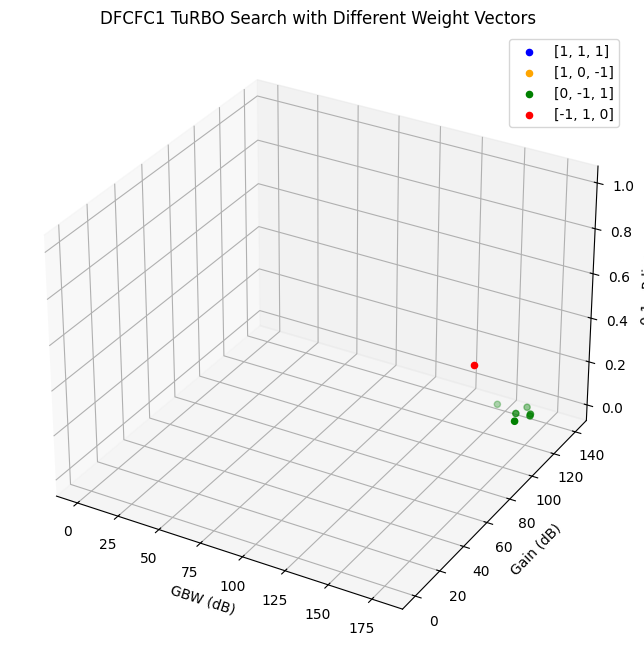

Searching for performance space for circuit: NGCC
------------------------------------------
Using performance weight: [1, 1, 1]
Using dtype = torch.float64 
Using device = cpu
Initalizing 5 trust regions with 60 random points each...
TR-0 starting from: -9.688
TR-1 starting from: 1
TR-2 starting from: -9.271
TR-3 starting from: -9.562
TR-4 starting from: 1
Starting optimization with 10 points per iteration...
310) New best @ TR-3: -9.785
320) New best @ TR-3: -9.872
380) New best @ TR-3: -9.893
iter_num: 10, n_evals: 400, current_iter_best: -9.893120202852598 
410) New best @ TR-3: -10.04
440) New best @ TR-3: -10.13
480) New best @ TR-3: -10.19
iter_num: 20, n_evals: 500, current_iter_best: -10.193042291361976 
530) New best @ TR-3: -10.23
550) New best @ TR-3: -10.25
570) New best @ TR-3: -10.29
iter_num: 30, n_evals: 600, current_iter_best: -10.286645864176599 
690) New best @ TR-3: -10.32
iter_num: 40, n_evals: 700, current_iter_best: -10.315909236765735 
710) New best @ TR-3: -10

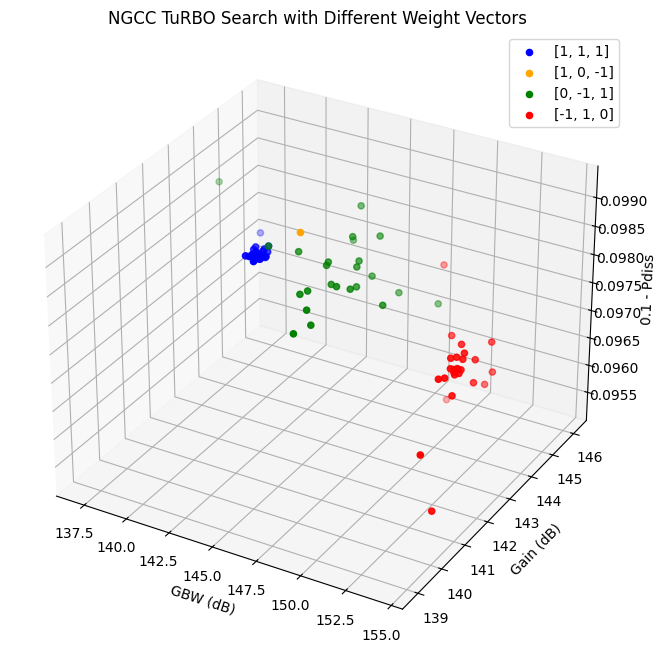

Searching for performance space for circuit: TCFC
------------------------------------------
Using performance weight: [1, 1, 1]
Using dtype = torch.float64 
Using device = cpu
Initalizing 5 trust regions with 52 random points each...
TR-0 starting from: -9.248
TR-1 starting from: -9.769
TR-2 starting from: -9.907
TR-3 starting from: 1
TR-4 starting from: -9.703
Starting optimization with 10 points per iteration...
280) New best @ TR-2: -10.07
330) New best @ TR-2: -10.21
iter_num: 10, n_evals: 360, current_iter_best: -10.212049652516274 
390) New best @ TR-2: -10.23
400) New best @ TR-2: -10.25
iter_num: 20, n_evals: 460, current_iter_best: -10.246511845062706 
iter_num: 30, n_evals: 560, current_iter_best: -10.246511845062706 
560) New best @ TR-1: -10.29
620) New best @ TR-1: -10.36
iter_num: 40, n_evals: 660, current_iter_best: -10.363834712232812 


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


690) New best @ TR-1: -10.39
700) New best @ TR-1: -10.42
740) New best @ TR-1: -10.44
iter_num: 50, n_evals: 760, current_iter_best: -10.442026561183011 
Finish! 
iter_num: 50, n_evals: 760, current_iter_best: -10.442026561183011 
Time cost: 1115.2352871894836 s 
Save current result to ./circuit_database/TCFC/result_1_1_1_20250521-200830.csv
------------------------------------------
Using performance weight: [1, 0, -1]
Using dtype = torch.float64 
Using device = cpu
Initalizing 5 trust regions with 52 random points each...
TR-0 starting from: -4.072
TR-1 starting from: -3.89
TR-2 starting from: 1
TR-3 starting from: 1
TR-4 starting from: -3.682
Starting optimization with 10 points per iteration...
270) New best @ TR-0: -4.768
290) New best @ TR-0: -5.57
320) New best @ TR-0: -5.584
350) New best @ TR-0: -5.604
iter_num: 10, n_evals: 360, current_iter_best: -5.6038796145216345 
420) New best @ TR-0: -5.714
430) New best @ TR-0: -5.773
iter_num: 20, n_evals: 460, current_iter_best: -5.

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


TR-0 starting from: 1
TR-1 starting from: -2.927
TR-2 starting from: -3.32
TR-3 starting from: 1
TR-4 starting from: -2.704
Starting optimization with 10 points per iteration...
260) New best @ TR-2: -3.377
270) New best @ TR-2: -3.434
280) New best @ TR-2: -3.792
320) New best @ TR-2: -3.867
350) New best @ TR-2: -3.902
iter_num: 10, n_evals: 360, current_iter_best: -3.9020332363335144 
370) New best @ TR-2: -4.14
390) New best @ TR-2: -4.433
400) New best @ TR-2: -4.816
iter_num: 20, n_evals: 460, current_iter_best: -4.8164932832244 
470) New best @ TR-2: -4.847
500) New best @ TR-2: -4.902
iter_num: 30, n_evals: 560, current_iter_best: -4.901983421778559 
580) New best @ TR-2: -4.922
590) New best @ TR-2: -5.007
iter_num: 40, n_evals: 660, current_iter_best: -5.006820363386568 
670) New best @ TR-2: -5.038
690) New best @ TR-2: -5.141
710) New best @ TR-2: -5.169
730) New best @ TR-2: -5.272
iter_num: 50, n_evals: 760, current_iter_best: -5.272362479037023 
Finish! 
iter_num: 50, n_

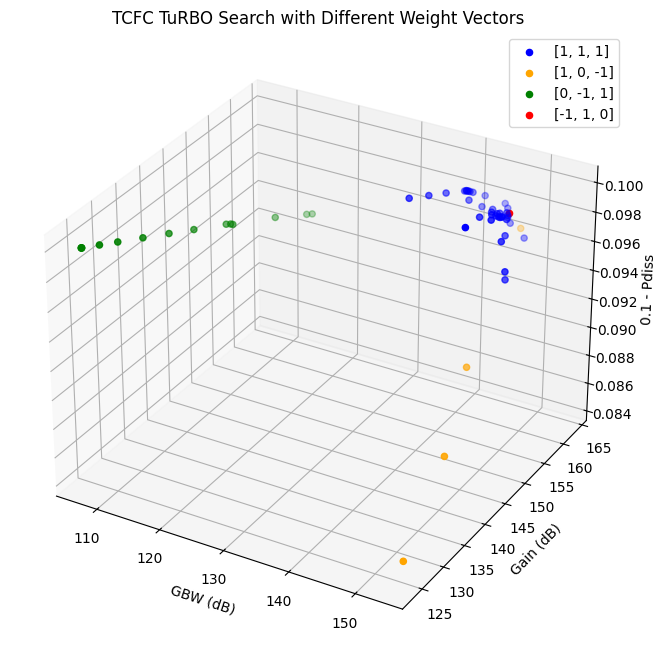

Searching for performance space for circuit: AZC
------------------------------------------
Using performance weight: [1, 1, 1]
Using dtype = torch.float64 
Using device = cpu
Initalizing 5 trust regions with 60 random points each...
TR-0 starting from: -5.657
TR-1 starting from: -5.557
TR-2 starting from: -4.869
TR-3 starting from: -5.698
TR-4 starting from: -6.334
Starting optimization with 10 points per iteration...


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


iter_num: 10, n_evals: 400, current_iter_best: -6.3339267827777865 
400) New best @ TR-0: -6.368
410) New best @ TR-0: -6.399
420) New best @ TR-0: -6.472
430) New best @ TR-0: -6.583
iter_num: 20, n_evals: 500, current_iter_best: -6.582844044311695 
550) New best @ TR-0: -6.6
560) New best @ TR-0: -6.611
570) New best @ TR-0: -6.664
iter_num: 30, n_evals: 600, current_iter_best: -6.663965440890676 
600) New best @ TR-0: -6.708
610) New best @ TR-0: -6.73
630) New best @ TR-0: -6.821
650) New best @ TR-0: -6.961
660) New best @ TR-0: -6.975
670) New best @ TR-0: -7.137
iter_num: 40, n_evals: 700, current_iter_best: -7.136667584383184 
710) New best @ TR-0: -7.222
720) New best @ TR-0: -7.282
730) New best @ TR-0: -7.326
750) New best @ TR-0: -7.584
760) New best @ TR-0: -7.813
780) New best @ TR-0: -7.865
iter_num: 50, n_evals: 800, current_iter_best: -7.865236127038467 
Finish! 
iter_num: 50, n_evals: 800, current_iter_best: -7.865236127038467 
Time cost: 1251.2481153011322 s 
Save cu

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


TR-0 starting from: 1
TR-1 starting from: -3.352
TR-2 starting from: -2.894
TR-3 starting from: -3.536
TR-4 starting from: 1
Starting optimization with 10 points per iteration...
310) New best @ TR-3: -3.691
320) New best @ TR-3: -3.708
330) New best @ TR-3: -3.734
iter_num: 10, n_evals: 400, current_iter_best: -3.7342892147566795 
iter_num: 20, n_evals: 500, current_iter_best: -3.7342892147566795 
iter_num: 30, n_evals: 600, current_iter_best: -3.7342892147566795 


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


iter_num: 40, n_evals: 700, current_iter_best: -3.7342892147566795 
iter_num: 50, n_evals: 800, current_iter_best: -3.7342892147566795 
Finish! 
iter_num: 50, n_evals: 800, current_iter_best: -3.7342892147566795 
Time cost: 952.2617168426514 s 
Save current result to ./circuit_database/AZC/result_0_-1_1_20250521-220650.csv
------------------------------------------
Using performance weight: [-1, 1, 0]
Using dtype = torch.float64 
Using device = cpu
Initalizing 5 trust regions with 60 random points each...
TR-0 starting from: 1
TR-1 starting from: 1


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


TR-2 starting from: 1
TR-3 starting from: 1
TR-4 starting from: 1
Starting optimization with 10 points per iteration...
iter_num: 10, n_evals: 400, current_iter_best: 1.0 
iter_num: 20, n_evals: 500, current_iter_best: 1.0 
iter_num: 30, n_evals: 600, current_iter_best: 1.0 
iter_num: 40, n_evals: 700, current_iter_best: 1.0 
iter_num: 50, n_evals: 800, current_iter_best: 1.0 
Finish! 
iter_num: 50, n_evals: 800, current_iter_best: 1.0 
Time cost: 1429.0942871570587 s 
Save current result to ./circuit_database/AZC/result_-1_1_0_20250521-223039.csv
------------------------------------------
Save all weights result to ./circuit_database/AZC/result_20250521-223039_allweights.csv


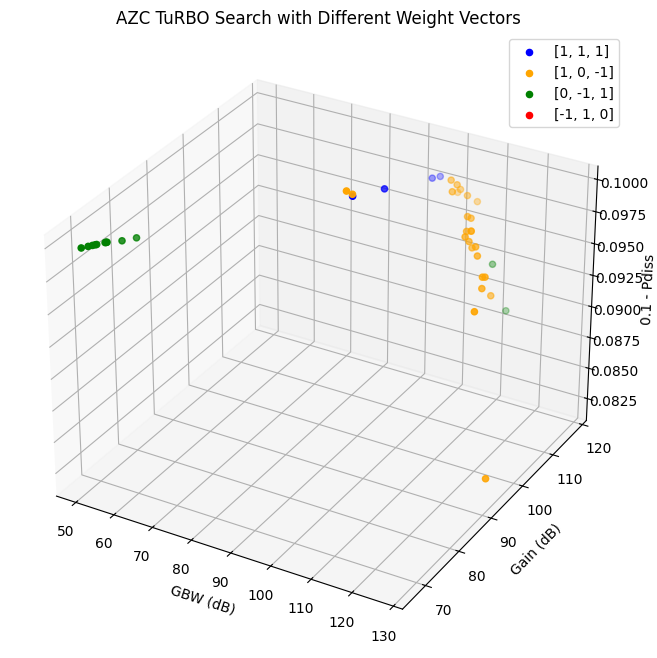

Searching for performance space for circuit: IAC
------------------------------------------
Using performance weight: [1, 1, 1]
Using dtype = torch.float64 
Using device = cpu
Initalizing 5 trust regions with 48 random points each...
TR-0 starting from: -8.656
TR-1 starting from: -8.632
TR-2 starting from: 1
TR-3 starting from: 1
TR-4 starting from: -8.064
Starting optimization with 10 points per iteration...
240) New best @ TR-0: -8.823
250) New best @ TR-0: -9.125
260) New best @ TR-0: -9.284
290) New best @ TR-0: -9.334
300) New best @ TR-0: -9.394
310) New best @ TR-0: -9.796
320) New best @ TR-0: -10.15
iter_num: 10, n_evals: 340, current_iter_best: -10.148999118397777 
400) New best @ TR-0: -10.28
iter_num: 20, n_evals: 440, current_iter_best: -10.284176745928903 
440) New best @ TR-0: -10.32
iter_num: 30, n_evals: 540, current_iter_best: -10.321845803891652 
600) TR-0 converged to: : -10.32
600) TR-0 is restarting from: : -9.724
iter_num: 40, n_evals: 688, current_iter_best: -10

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


340) New best @ TR-0: -7.423
400) New best @ TR-0: -7.453
iter_num: 20, n_evals: 440, current_iter_best: -7.452965183672385 
470) New best @ TR-0: -7.531
480) New best @ TR-0: -7.565
500) New best @ TR-0: -7.669
iter_num: 30, n_evals: 540, current_iter_best: -7.6689863360107635 
540) New best @ TR-0: -7.686
580) New best @ TR-0: -7.711
590) New best @ TR-0: -7.724
630) TR-0 converged to: : -7.725
630) TR-0 is restarting from: : 1
iter_num: 40, n_evals: 688, current_iter_best: -7.724281350261181 


Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


iter_num: 50, n_evals: 788, current_iter_best: -7.724281350261181 
Finish! 
iter_num: 50, n_evals: 788, current_iter_best: -7.724281350261181 
Time cost: 957.7947080135345 s 
Save current result to ./circuit_database/IAC/result_-1_1_0_20250521-232905.csv
------------------------------------------
Save all weights result to ./circuit_database/IAC/result_20250521-232905_allweights.csv


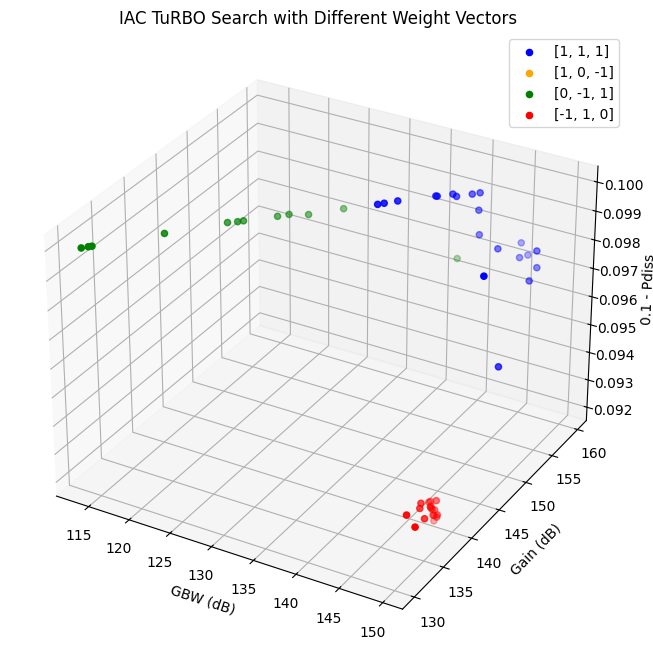

In [3]:
# SMC/NMCNR/DFCFC1/NGCC/TCFC/AZC/IAC
# circuit_lists = [ 'NMCNR', 'DFCFC1', 'NGCC', 'TCFC', 'AZC', 'IAC']
circuit_lists = [ 'DFCFC1', 'NGCC', 'TCFC', 'AZC', 'IAC']

for ckt_name in circuit_lists:
    
    technique_path = './circuits/design_space.json'
    scs_mdl_path = './circuits'
    run_path = './runs'
    database_path = './circuit_database'
    
    # Check if there is a directory of scs and mdl files for the circuit
    if not os.path.exists(scs_mdl_path+'/'+ckt_name):
        print(f'\033[31mPlease add netlist and testbench files (in the format of scs and mdl) for the circuit [{ckt_name}] before running the Benchmark\033[0m')
        
    scs_mdl_paths = [
        {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.mdl', 'name': 'da'},
        {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.mdl', 'name': 'tran'},
        ]
    
    if not os.path.exists(database_path+'/'+ckt_name):
        os.system(f'mkdir {database_path}/{ckt_name}')
        
        # raw/ stores original netlists and test files
        os.system(f'mkdir {database_path}/{ckt_name}/raw')
        os.system(f'cp {scs_mdl_path}/{ckt_name}/* {database_path}/{ckt_name}/raw')
        
        # result.csv stores high-performing metrics and parameter pairs discovered during exploration
        os.system(f'touch {database_path}/{ckt_name}/result.csv')
        # The CSV header is GBW, Gain, Pdiss, time, performance weight, solution vector, solution path
        with open(f'{database_path}/{ckt_name}/result.csv', 'w') as f:
            f.write('GBW, Gain, Pdiss, Fitness, time, performance weight, solution vector, solution path\n')
        
        # result_folder stores complete netlists and simulation results corresponding to the performance metrics
        os.system(f'mkdir {database_path}/{ckt_name}/result_folder')
        
    circuit = CircuitParams(scs_mdl_paths[0]["scs"], technique_path)

    dim = len(circuit.variables)

    performance_weights = [
        [1, 1, 1],
        [1, 0, -1],
        [0, -1, 1],
        [-1, 1, 0]
        ]
    
    print(f'\033[32mSearching for performance space for circuit: {ckt_name}\033[0m') 
    print('------------------------------------------')
    # Try other performance-metric weights
    for performance_weight in performance_weights:
        print(f'\033[32mUsing performance weight: {performance_weight}\033[0m')

        fitness_function = make_fitness_function(performance_weight[0], performance_weight[1], performance_weight[2])

        f = FitnessFunction_Prallel_Tailor(scs_mdl_paths, run_path, ckt_name, [], circuit.params, circuit.wsub, fitness_function, database_path, performance_weight)

        Chat_Turbom_Plus = TurboM_Plus(
            f=f,
            lb=np.array(circuit.lb),
            ub=np.array(circuit.ub),
            n_init=2*dim,  # number of initial points for each trust region, fix the value to 10 or 2*dim
            max_evals=99999,
            max_iters=50,    # Check carefully
            n_trust_regions=5,  # TuRBOm, m
            batch_size=10,
            x_init=None, # or circuit.vector (in 1024version or after, this should be vectorS, which is a list of vectors)
            device='cpu',
        )

        start_time = time.time()
        Chat_Turbom_Plus.optimize()
        end_time = time.time()
        print(f"\033[31mTime cost: {end_time-start_time} s \033[0m")
        
        # After each weight finishes, save another timestamped CSV with the current weight
        time_stamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
        save_file_path = f'{database_path}/{ckt_name}/result_{performance_weight[0]}_{performance_weight[1]}_{performance_weight[2]}_{time_stamp}.csv'
        os.system(f'cp {database_path}/{ckt_name}/result.csv {save_file_path}')
        print(f'\033[32mSave current result to {save_file_path}\033[0m')
        
        # For weight [1, 1, 1], plot the search path once
        if performance_weight == (1, 1, 1):
            draw_search_path(f'{database_path}/{ckt_name}/result.csv', ckt_name, weight_vector='[1, 1, 1]')

        # separating line
        print('------------------------------------------')
        
    # Save once more after all weights finish
    time_stamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
    save_file_path = f'{database_path}/{ckt_name}/result_{time_stamp}_allweights.csv'
    os.system(f'cp {database_path}/{ckt_name}/result.csv {save_file_path}')
    print(f'\033[32mSave all weights result to {save_file_path}\033[0m')

    # Plot the TuRBO Pareto front once
    draw_pareto_TuRBO(f'{database_path}/{ckt_name}/result.csv', ckt_name)